In [1]:
import sys 
from pathlib import Path 
sys.path.append(str(Path().resolve().parents[0]))

import pandas as pd 
import matplotlib.pyplot as plt

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR

In [2]:
pokemon_df = pd.read_csv(RAW_DATA_DIR / "pokedex.csv")

In [3]:
print(f"Dataset shape: {pokemon_df.shape[0]} rows and {pokemon_df.shape[1]} columns")

Dataset shape: 1045 rows and 56 columns


In [4]:
def create_histogram(df: pd.DataFrame, col: str) -> None:
    """Create a histogram and display skewness"""
    if col not in df.columns:
        raise ValueError("Passed in column not present in dataframe")
    
    skew = df[col].skew()
    plt.hist(df[col], edgecolor="black")
    plt.title(f"Distribution of {col} - Skew: {skew:.2f}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


def impute_value(df: pd.DataFrame, col: str, round_to_int: bool = True) -> pd.DataFrame:
    """Impute missing numerical values with the median, preserving floats when needed."""
    df = df.copy()
    fill_value = df[col].median()
    df[col] = df[col].fillna(fill_value)
    if round_to_int:
        df[col] = df[col].round().astype(int)
    return df


def clean_str_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    str_cols = df.select_dtypes(include=["object", "string"]).columns

    df[str_cols] = (
        df[str_cols]
        .apply(lambda col: col.str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
    )

    return df

In [5]:
print(pokemon_df.columns)

Index(['Unnamed: 0', 'pokedex_number', 'name', 'japanese_name', 'generation',
       'status', 'species', 'type_number', 'type_1', 'type_2', 'height_m',
       'weight_kg', 'abilities_number', 'total_points', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'catch_rate',
       'base_friendship', 'base_experience', 'growth_rate', 'egg_type_number',
       'egg_type_1', 'egg_type_2', 'percentage_male', 'egg_cycles',
       'against_normal', 'against_fire', 'against_water', 'against_electric',
       'against_grass', 'against_ice', 'against_fight', 'against_poison',
       'against_ground', 'against_flying', 'against_psychic', 'against_bug',
       'against_rock', 'against_ghost', 'against_dragon', 'against_dark',
       'against_steel', 'against_fairy', 'smogon_description',
       'bulba_description', 'moves', 'ability_1', 'ability_2',
       'ability_hidden', 'ability_1_description', 'ability_2_description',
       'ability_hidden_description'],
      dtype='str')

In [6]:
# Keep columns only necessary for modeling purpose
pokemon_df = pokemon_df.drop(
    columns= [
        "Unnamed: 0",
        "pokedex_number",
        "japanese_name",
        "species",
        "moves",
        "smogon_description",
        "bulba_description",
        "ability_1_description",
        "ability_2_description",
        "ability_hidden_description",
        "hp",
        "attack",
        "defense",
        "sp_attack",
        "sp_defense",
        "speed",
        "egg_type_1",
        "egg_type_2",
        "egg_type_number",
        "percentage_male",
        "egg_cycles"
    ]
)

# Display remaining columns
print(pokemon_df.columns)

Index(['name', 'generation', 'status', 'type_number', 'type_1', 'type_2',
       'height_m', 'weight_kg', 'abilities_number', 'total_points',
       'catch_rate', 'base_friendship', 'base_experience', 'growth_rate',
       'against_normal', 'against_fire', 'against_water', 'against_electric',
       'against_grass', 'against_ice', 'against_fight', 'against_poison',
       'against_ground', 'against_flying', 'against_psychic', 'against_bug',
       'against_rock', 'against_ghost', 'against_dragon', 'against_dark',
       'against_steel', 'against_fairy', 'ability_1', 'ability_2',
       'ability_hidden'],
      dtype='str')


In [7]:
# Display dtype of each column
# Mainly check the numerical columns are the proper type (e.g., not object dtype)
print(pokemon_df.dtypes)

name                    str
generation            int64
status                  str
type_number           int64
type_1                  str
type_2                  str
height_m            float64
weight_kg           float64
abilities_number      int64
total_points          int64
catch_rate          float64
base_friendship     float64
base_experience     float64
growth_rate             str
against_normal      float64
against_fire        float64
against_water       float64
against_electric    float64
against_grass       float64
against_ice         float64
against_fight       float64
against_poison      float64
against_ground      float64
against_flying      float64
against_psychic     float64
against_bug         float64
against_rock        float64
against_ghost       float64
against_dragon      float64
against_dark        float64
against_steel       float64
against_fairy       float64
ability_1               str
ability_2               str
ability_hidden          str
dtype: object


In [8]:
# Handle missing values 
print(pokemon_df.isna().sum())

name                  0
generation            0
status                0
type_number           0
type_1                0
type_2              492
height_m              0
weight_kg             1
abilities_number      0
total_points          0
catch_rate           18
base_friendship     115
base_experience     120
growth_rate           1
against_normal        0
against_fire          0
against_water         0
against_electric      0
against_grass         0
against_ice           0
against_fight         0
against_poison        0
against_ground        0
against_flying        0
against_psychic       0
against_bug           0
against_rock          0
against_ghost         0
against_dragon        0
against_dark          0
against_steel         0
against_fairy         0
ability_1             1
ability_2           106
ability_hidden      393
dtype: int64


In [9]:
# For missing type_2 values, infer that the Pokemon only has one type
pokemon_df["type_2"] = pokemon_df["type_2"].fillna("None")

# Verify that missing values for type_2 are resolved 
pokemon_df["type_2"].isna().sum()

np.int64(0)

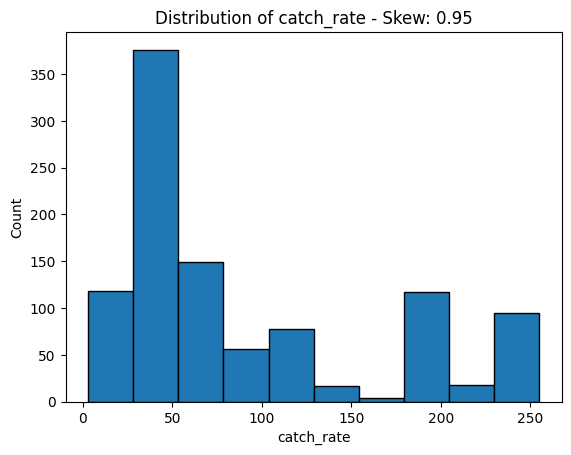

In [10]:
create_histogram(pokemon_df, "catch_rate")

In [11]:
# Since skewness of catch rate is moderate, impute missing values with median of total column 
pokemon_df = impute_value(pokemon_df, "catch_rate")

# Verify missingness is resolved 
print(pokemon_df["catch_rate"].isna().sum())

0


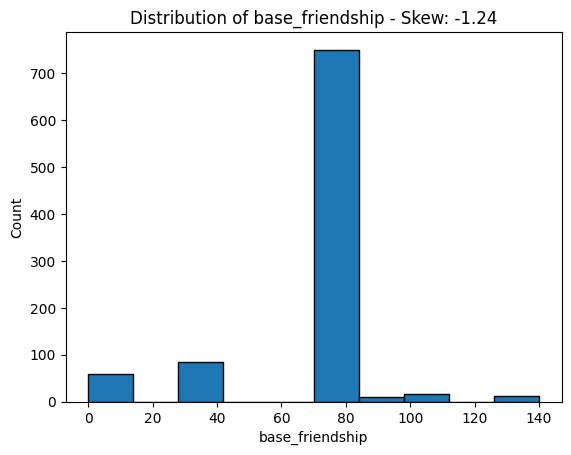

In [12]:
create_histogram(pokemon_df, "base_friendship")

In [13]:
pokemon_df = impute_value(pokemon_df, "base_friendship")

print(pokemon_df["base_friendship"].isna().sum())

0


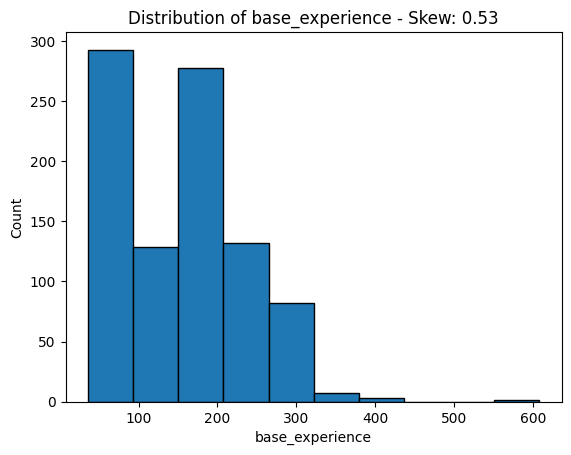

In [14]:
create_histogram(pokemon_df, "base_experience")

In [15]:
pokemon_df = impute_value(pokemon_df, "base_experience")
print(pokemon_df["base_experience"].isna().sum())

0


In [16]:
# Regidrago is missing ability_1 in the source data; patch it explicitly instead of dropping the row
pokemon_df.loc[1039, "ability_1"] = "Dragon's Maw"

print(pokemon_df["ability_1"].isna().sum())

0


In [17]:
# Not all Pokemon have a 2nd ability or hidden one, replace all missing values with None
pokemon_df["ability_2"] = pokemon_df["ability_2"].fillna("None")
pokemon_df["ability_hidden"] = pokemon_df["ability_hidden"].fillna("None")

print(pokemon_df["ability_2"].isna().sum())
print(pokemon_df["ability_hidden"].isna().sum())

0
0


In [18]:
# Impute weight_kg for singular missing value while preserving decimal precision
pokemon_df = impute_value(pokemon_df, "weight_kg", round_to_int=False)

print(pokemon_df["weight_kg"].isna().sum())

0


In [19]:
# Since growth rate is categorical, impute missing value with mode 
pokemon_df["growth_rate"] = pokemon_df["growth_rate"].fillna(
    pokemon_df["growth_rate"].mode()[0]
)

print(pokemon_df["growth_rate"].isna().sum())

0


In [20]:
for col in pokemon_df.columns:
    assert pokemon_df[col].isna().sum() == 0

print("No missing values present!")
print(pokemon_df.isna().sum())

No missing values present!
name                0
generation          0
status              0
type_number         0
type_1              0
type_2              0
height_m            0
weight_kg           0
abilities_number    0
total_points        0
catch_rate          0
base_friendship     0
base_experience     0
growth_rate         0
against_normal      0
against_fire        0
against_water       0
against_electric    0
against_grass       0
against_ice         0
against_fight       0
against_poison      0
against_ground      0
against_flying      0
against_psychic     0
against_bug         0
against_rock        0
against_ghost       0
against_dragon      0
against_dark        0
against_steel       0
against_fairy       0
ability_1           0
ability_2           0
ability_hidden      0
dtype: int64


In [21]:
pokemon_df = clean_str_columns(pokemon_df)

In [22]:
pokemon_df.to_parquet(PROCESSED_DATA_DIR / "pokemon_data_clean.parquet", index=False)